自检一：覆盖度校验（用 selftest 表）
因子数据形状: (197823, 3)
最大缺失率: 0.0000
开头几天缺失率:
date
2024-01-02    0.0
2024-01-03    0.0
2024-01-04    0.0
2024-01-05    0.0
2024-01-08    0.0
2024-01-09    0.0
dtype: float64
✅ 覆盖度自检通过

自检二：未来函数检测（selftest vs ahead）
⚠️ lookahead_selfcheck 模块未安装
   请运行: pip install lookahead-selfcheck

自检三：官方评估（正式数据表）
[2026-07-22 16:15:08] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-22 16:15:42] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-22 16:15:43] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-22 16:15:46] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-22 16:15:47] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-22 16:15:50] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-30
[2026-07-22 16:15:50] [info     ] ========== 数据检查 ==========
[2026-07-22 16:15:50] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume',

时段,IC
2024-01-15~2024-02-08,0.0040
2024-09-24~2024-10-08,0.0128

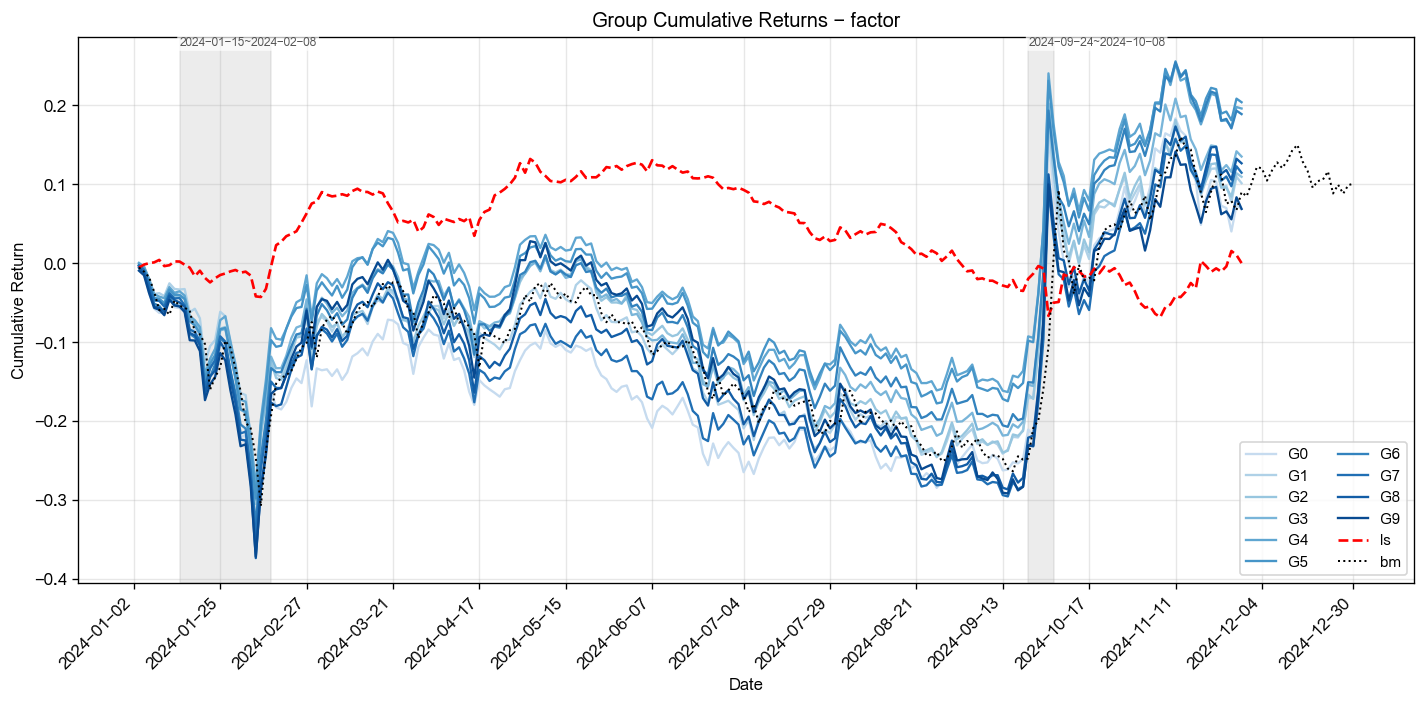
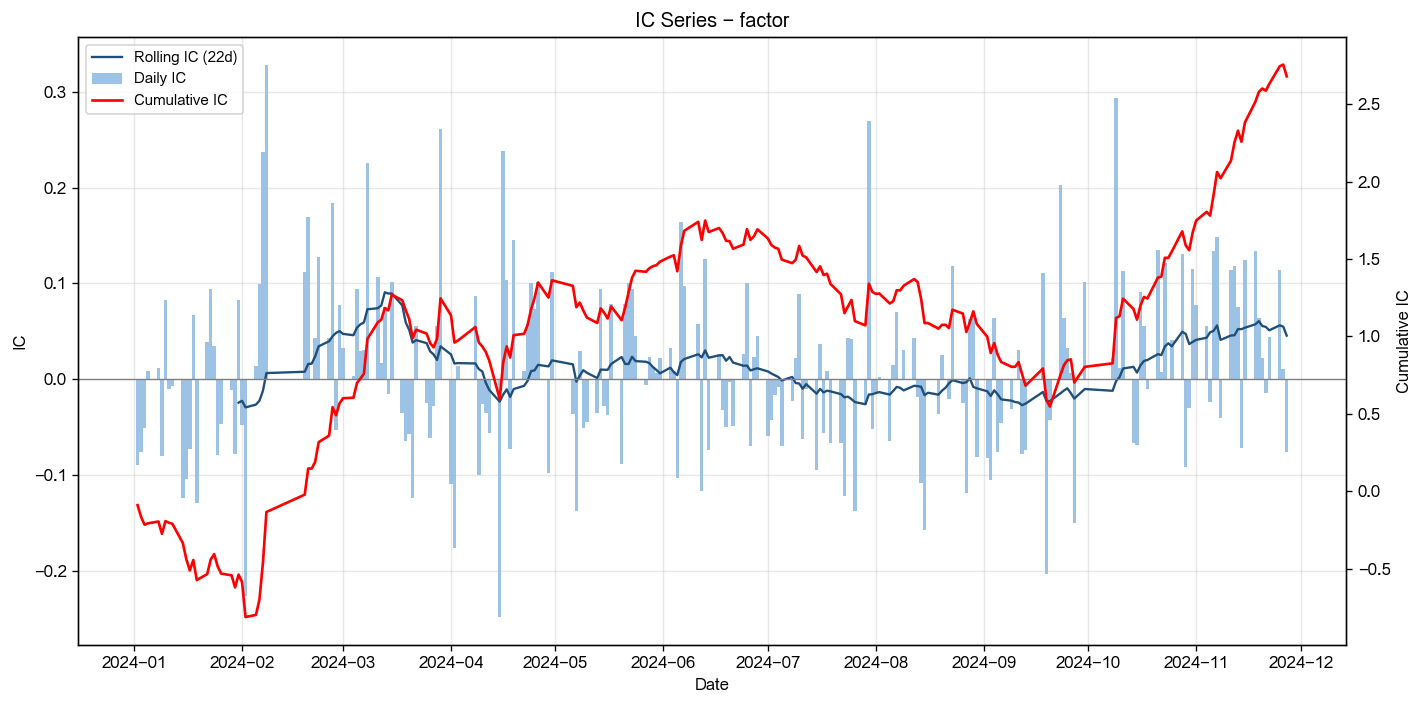
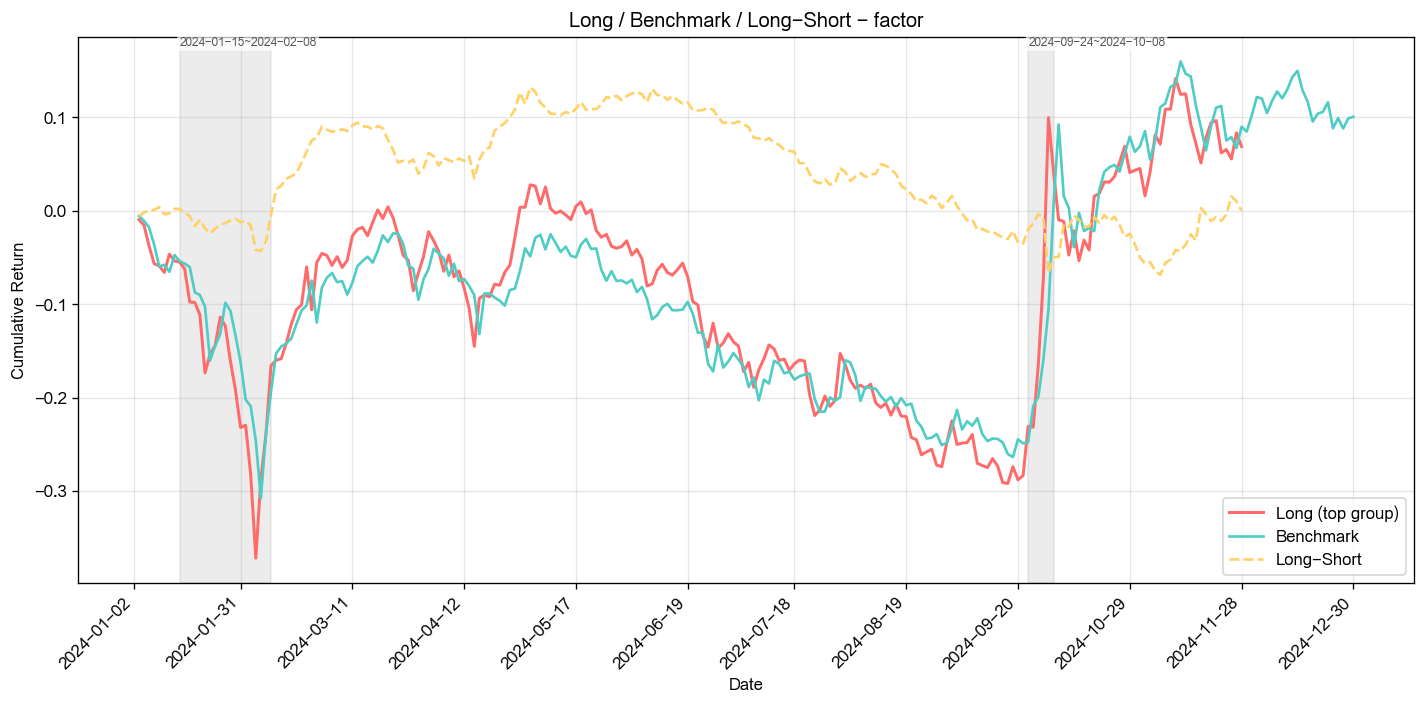
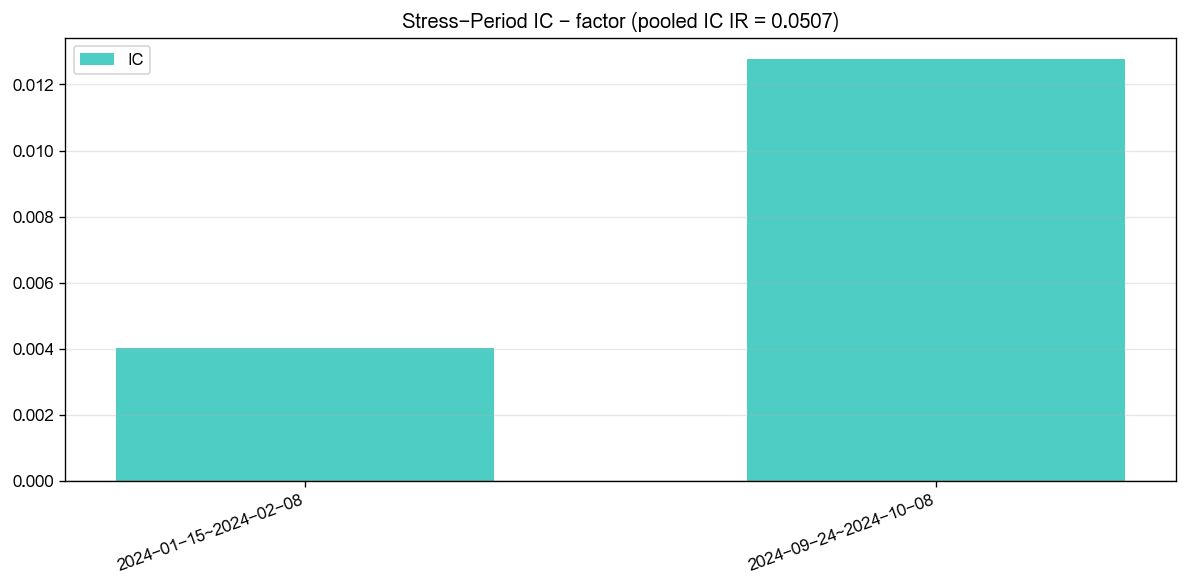
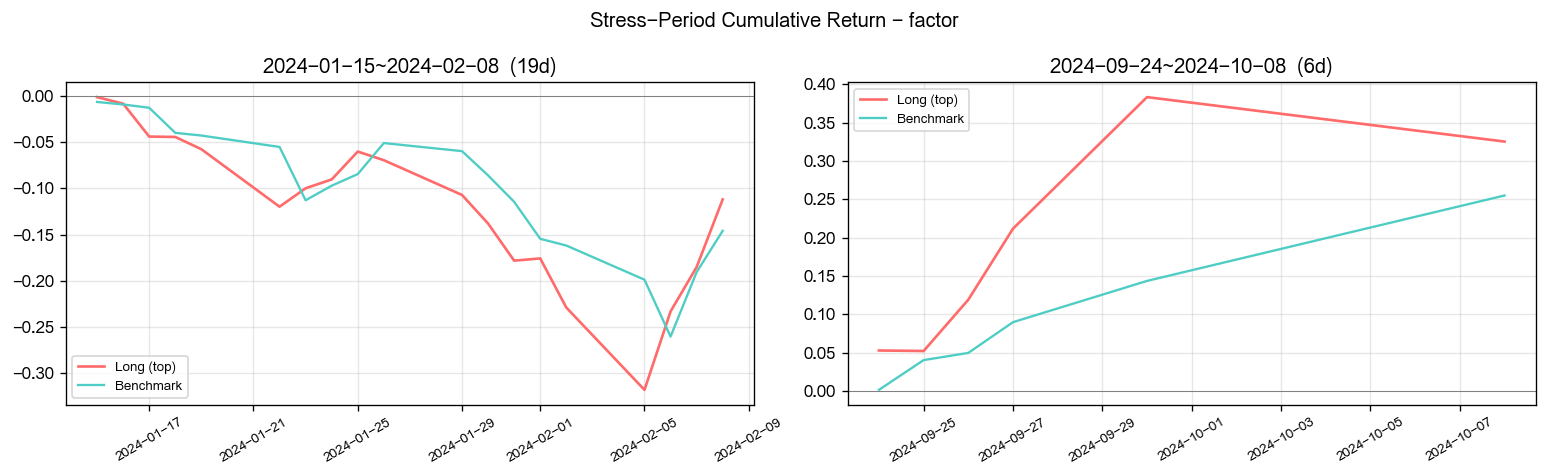

[2026-07-22 16:18:17] [info     ] ========== 因子池回归 ==========
[2026-07-22 16:18:18] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-30 instrument_count=1206 rows=296765 start_date=2024-01-02
[2026-07-22 16:18:22] [info     ] 获取收益率数据, 耗时: 4.26 秒
[2026-07-22 16:18:25] [info     ] 滚动 Elastic Net 拟合, 耗时: 2.9216 秒
[2026-07-22 16:18:25] [info     ] 统计 回归结果, 耗时: 0.0079 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9401,0.0466,0.0240,1.0000
2,amount,1.7595,0.0190,0.0108,0.9000
3,factor,1.6264,0.0238,0.0146,1.0000
4,gross_profit_rate_ttm,1.5407,0.0070,0.0046,1.0000
5,netflow_amount_main,1.4905,0.0250,0.0168,1.0000
6,net_profit_rate_ttm,1.4647,0.0041,0.0028,0.8000
7,netflow_amount_rate_main,1.4424,0.0079,0.0055,1.0000
8,bias_20,1.4226,0.0283,0.0199,0.9000
9,pb,1.4105,0.0096,0.0068,0.9000
10,cci_14,1.3430,0.0292,0.0217,1.0000

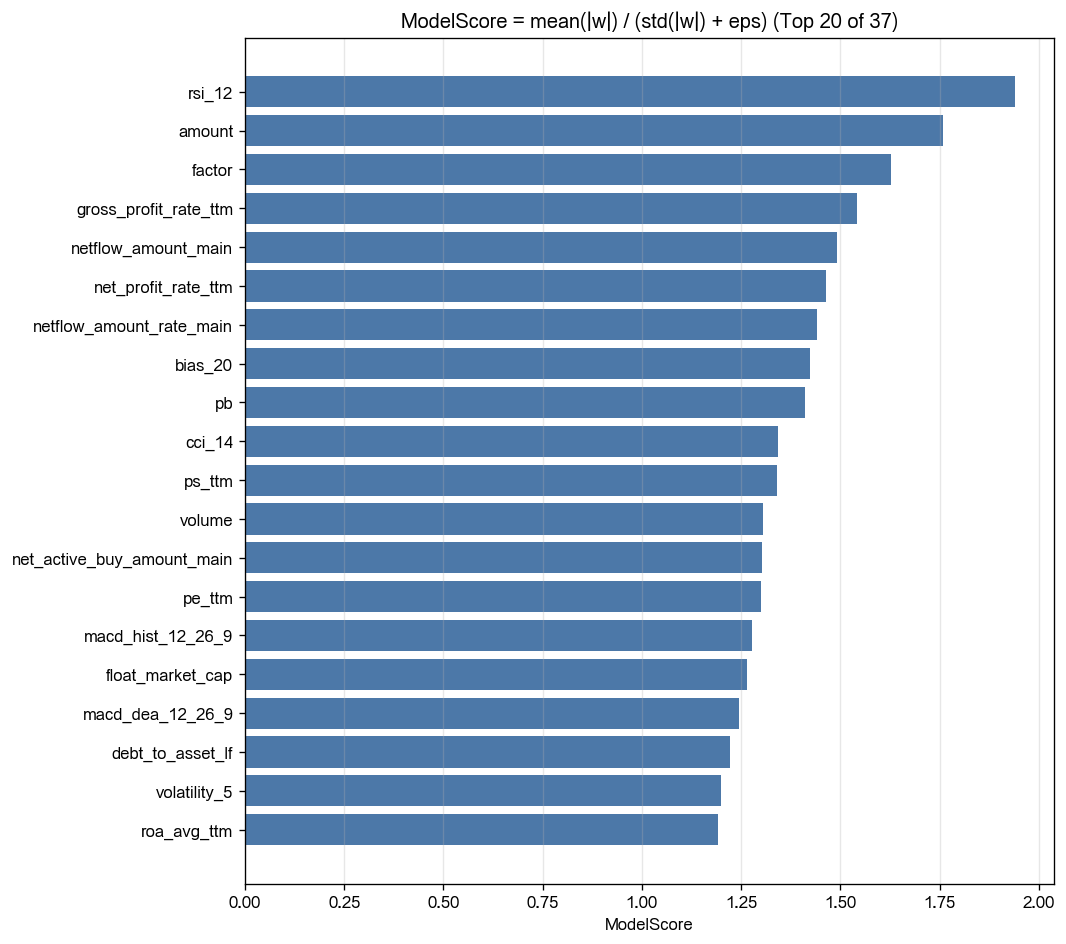
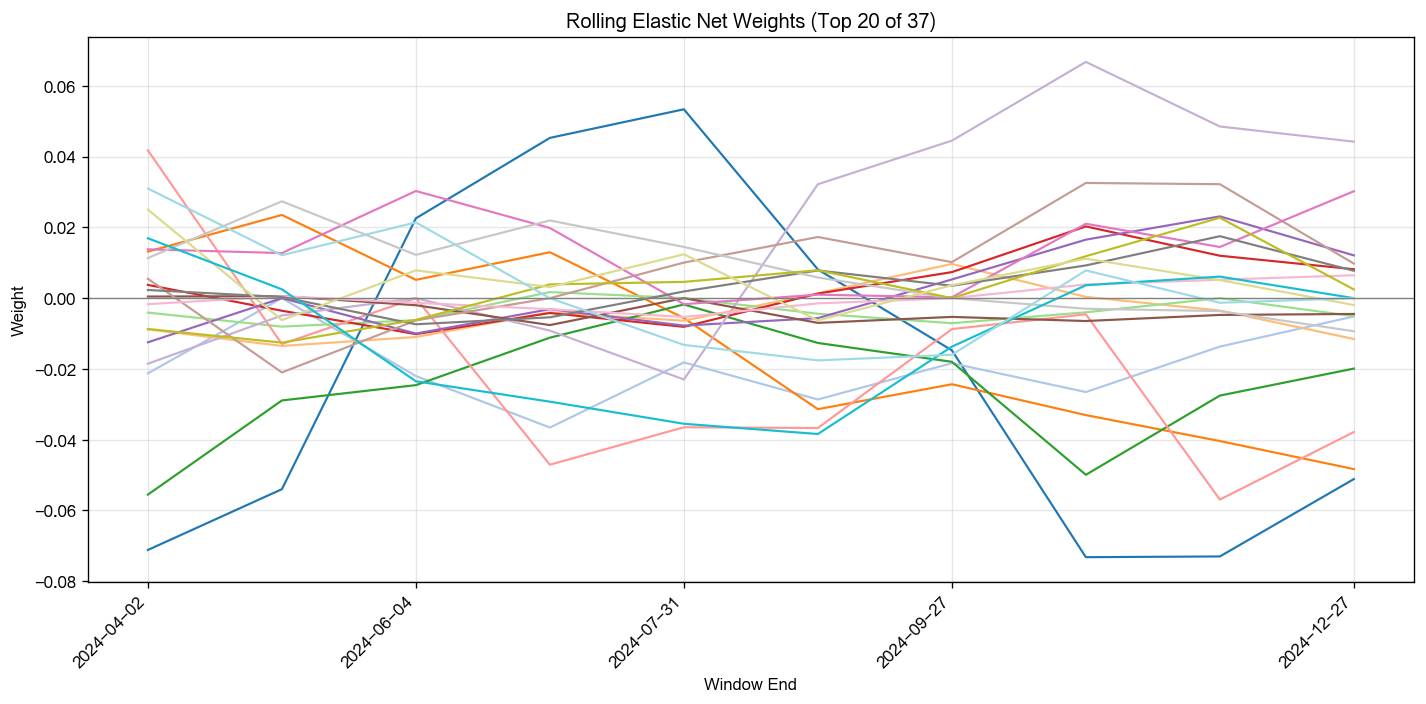
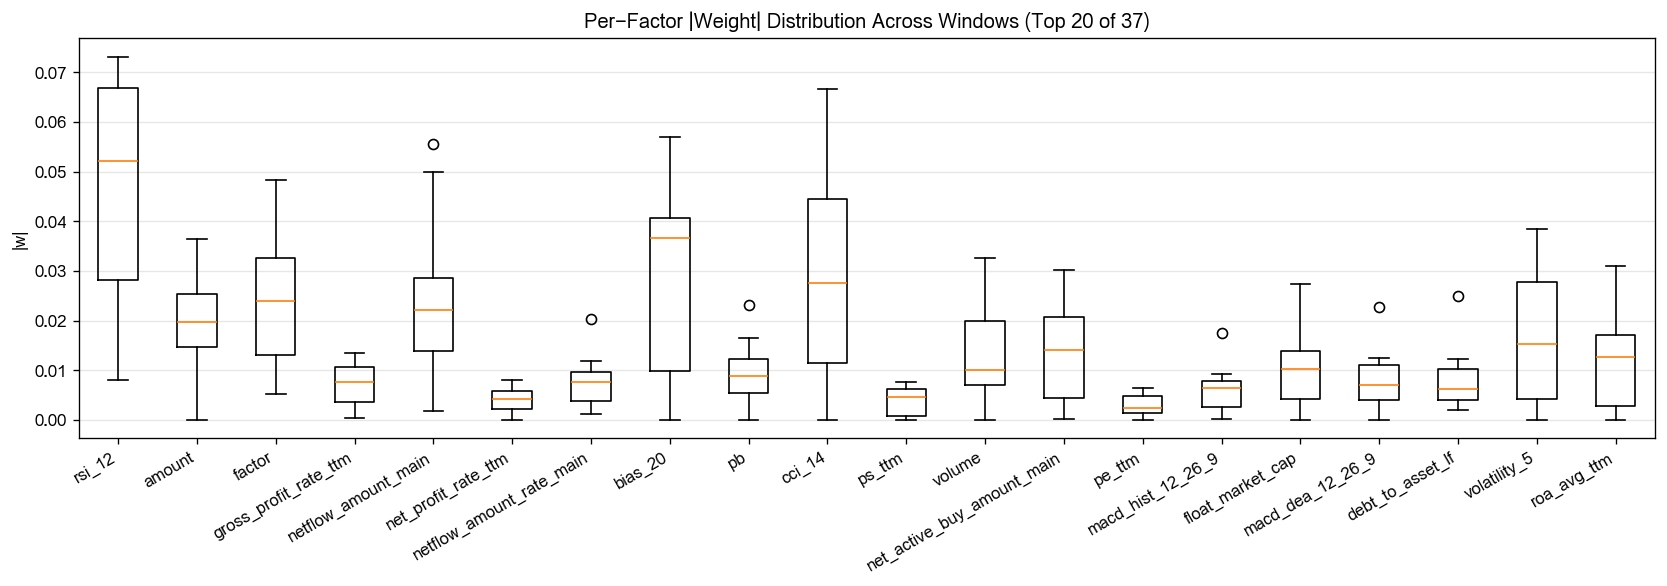
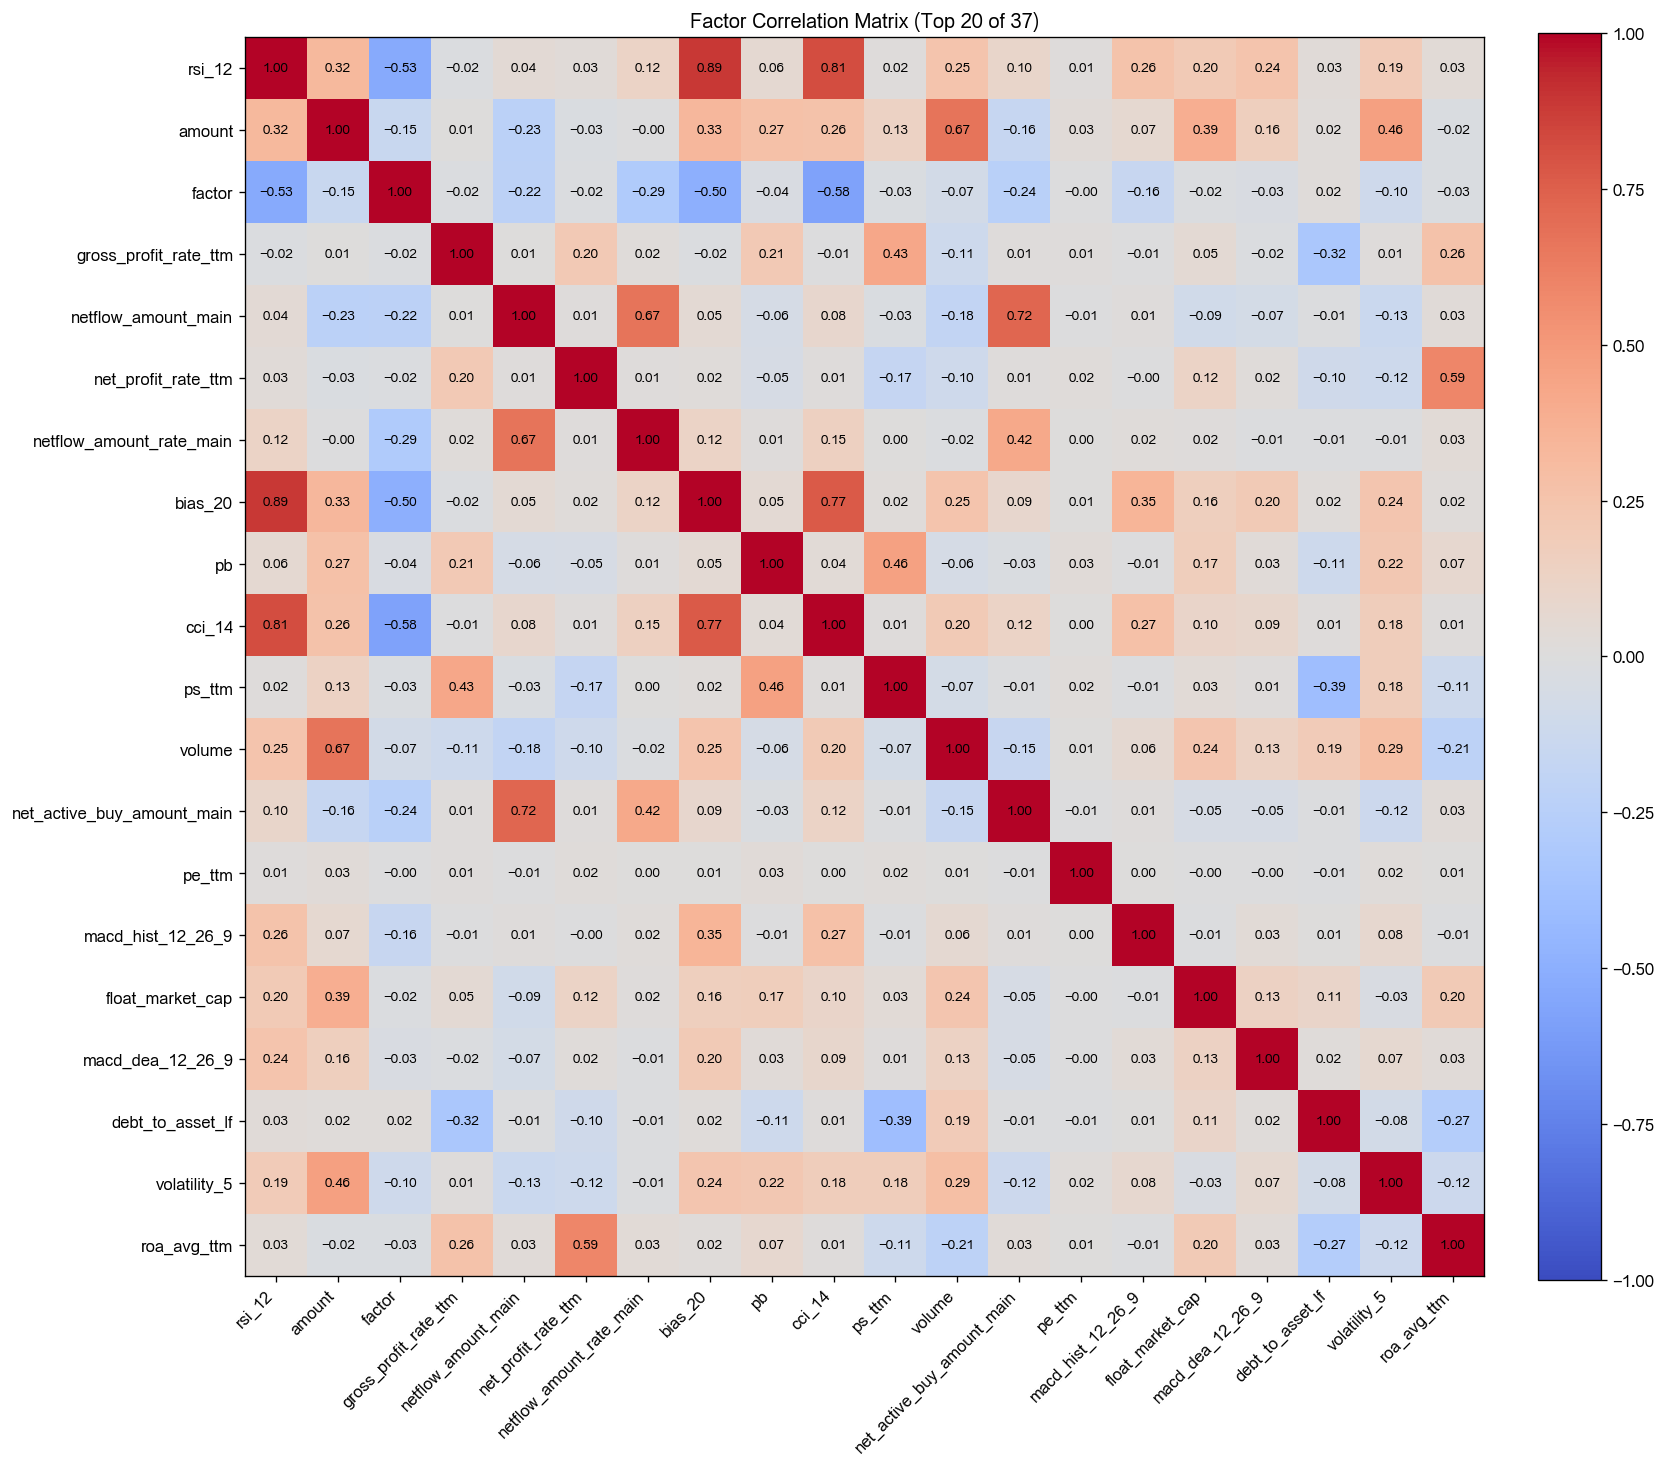

[2026-07-22 16:18:27] [warning  ] 返回的Outputs实例(size=33372207) 大于 64K, 将不会被缓存
[2026-07-22 16:18:27] [info     ] bigalpha_eval.v4 运行完成 [161.532s].
正式数据最大缺失率: 0.0000


In [1]:
import pandas as pd
import numpy as np
import dai
import structlog

logger = structlog.get_logger()

def main(datasources, start_date, end_date):
    """
    基于分钟线构建复合因子（全 SQL 聚合）

    遵循官方文档要求：
        1. 手动向前扩查询窗口（BUFFER_DAYS=90）
        2. last() / first() 均带 ORDER BY date 确定性排序
        3. 输出裁回 [start_date, end_date]
        4. 降序百分位排名，因子值越大越好

    子因子：
        f1: VWAP 动量（今日VWAP/昨日VWAP-1）
        f2: 5日收盘价动量
        f3: 成交量相对均值
        f4: VWAP 本身
        f5: 动量/成交量
        f6: 日收益率符号
        f7: 价格偏离5日均线
        f8: 布林带位置
    """
    bar_table = datasources.get("bar1m")
    if not bar_table:
        logger.error("未提供 bar1m 数据源")
        return pd.DataFrame(columns=["date", "instrument", "factor"])

    start_ts = pd.Timestamp(start_date).normalize()
    end_ts = pd.Timestamp(end_date).normalize()

    # ===== 关键：手动向前扩查询窗口 =====
    # 官方文档：验证集数据实际比 start_date 多向前备了约3个月
    # 必须在 main() 内部手动扩窗，才能吃到这段缓冲
    # 经验：按最长窗口（20日均线）的 2~3 倍估算自然日
    BUFFER_DAYS = 90
    query_start_ts = start_ts - pd.Timedelta(days=BUFFER_DAYS)

    sql = f"""
    WITH daily AS (
        SELECT
            instrument,
            strftime(date, '%Y-%m-%d') AS trading_day,
            -- ✅ 所有聚合都带 ORDER BY date，确保确定性
            first(open  ORDER BY date) AS open,
            last(close ORDER BY date) AS close,
            max(high) AS high,
            min(low) AS low,
            sum(volume) AS volume,
            sum(amount) AS amount,
            sum(amount) / nullif(sum(volume), 0) AS vwap
        FROM {bar_table}
        WHERE close > 0
        GROUP BY instrument, strftime(date, '%Y-%m-%d')
    ),
    with_lags AS (
        SELECT
            trading_day,
            instrument,
            close,
            volume,
            amount,
            vwap,
            -- f1: VWAP 动量（LAG 取昨日）
            lag(vwap, 1) OVER (PARTITION BY instrument ORDER BY trading_day) AS vwap_lag1,
            -- f2: 5日动量（LAG 取5日前）
            lag(close, 5) OVER (PARTITION BY instrument ORDER BY trading_day) AS close_lag5,
            -- f3: 成交量相对均值（过去5日平均，不含当日）
            avg(volume) OVER (PARTITION BY instrument ORDER BY trading_day ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING) AS volume_avg5,
            -- f6: 日收益率（LAG 取昨日）
            lag(close, 1) OVER (PARTITION BY instrument ORDER BY trading_day) AS close_lag1,
            -- f7: 5日均线（含当日）
            avg(close) OVER (PARTITION BY instrument ORDER BY trading_day ROWS BETWEEN 4 PRECEDING AND CURRENT ROW) AS close_avg5,
            -- f8: 20日均线和标准差
            avg(close) OVER (PARTITION BY instrument ORDER BY trading_day ROWS BETWEEN 19 PRECEDING AND CURRENT ROW) AS close_avg20,
            stddev_samp(close) OVER (PARTITION BY instrument ORDER BY trading_day ROWS BETWEEN 19 PRECEDING AND CURRENT ROW) AS close_std20
        FROM daily
    ),
    factors AS (
        SELECT
            CAST(trading_day AS DATETIME) AS date,
            instrument,
            (vwap / nullif(vwap_lag1, 0) - 1) AS f1,
            (close / nullif(close_lag5, 0) - 1) AS f2,
            volume / nullif(volume_avg5, 0) AS f3,
            vwap AS f4,
            (close / nullif(close_lag5, 0) - 1) / nullif(volume, 0) AS f5,
            sign(close / nullif(close_lag1, 0) - 1) AS f6,
            (close - close_avg5) / nullif(close, 0) AS f7,
            (close - close_avg20) / nullif(2 * close_std20, 0) AS f8
        FROM with_lags
        WHERE close_lag5 IS NOT NULL
          AND volume_avg5 IS NOT NULL
    ),
    zscored AS (
        SELECT
            date,
            instrument,
            (f1 - avg(f1) OVER (PARTITION BY date)) / nullif(stddev_samp(f1) OVER (PARTITION BY date), 0) AS z1,
            (f2 - avg(f2) OVER (PARTITION BY date)) / nullif(stddev_samp(f2) OVER (PARTITION BY date), 0) AS z2,
            (f3 - avg(f3) OVER (PARTITION BY date)) / nullif(stddev_samp(f3) OVER (PARTITION BY date), 0) AS z3,
            (f4 - avg(f4) OVER (PARTITION BY date)) / nullif(stddev_samp(f4) OVER (PARTITION BY date), 0) AS z4,
            (f5 - avg(f5) OVER (PARTITION BY date)) / nullif(stddev_samp(f5) OVER (PARTITION BY date), 0) AS z5,
            (f6 - avg(f6) OVER (PARTITION BY date)) / nullif(stddev_samp(f6) OVER (PARTITION BY date), 0) AS z6,
            (f7 - avg(f7) OVER (PARTITION BY date)) / nullif(stddev_samp(f7) OVER (PARTITION BY date), 0) AS z7,
            (f8 - avg(f8) OVER (PARTITION BY date)) / nullif(stddev_samp(f8) OVER (PARTITION BY date), 0) AS z8
        FROM factors
    ),
    raw_score AS (
        SELECT
            date,
            instrument,
            coalesce(z1, 0) + coalesce(z2, 0) + coalesce(z3, 0) +
            coalesce(z4, 0) + coalesce(z5, 0) + coalesce(z6, 0) +
            coalesce(z7, 0) + coalesce(z8, 0) AS raw_score
        FROM zscored
    ),
    final_factor AS (
        SELECT
            date,
            instrument,
            -- 降序排名，反转短期反转信号为正向因子
            (rank() OVER (PARTITION BY date ORDER BY raw_score DESC) - 1) * 1.0 /
            (count(*) OVER (PARTITION BY date) - 1) AS factor
        FROM raw_score
        WHERE raw_score IS NOT NULL
    )
    SELECT date, instrument, factor
    FROM final_factor
    """

    try:
        # ===== 查询时使用扩窗后的下界 =====
        df = dai.query(
            sql,
            filters={"date": [query_start_ts.strftime("%Y-%m-%d %H:%M:%S"), end_ts.strftime("%Y-%m-%d %H:%M:%S")]},
            compression=True
        ).df()
    except Exception as e:
        logger.error(f"SQL 执行失败: {e}")
        return pd.DataFrame(columns=["date", "instrument", "factor"])

    if df.empty:
        return pd.DataFrame(columns=["date", "instrument", "factor"])

    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    df["instrument"] = df["instrument"].astype(str)

    # ===== 关键：裁回真正的评估区间 =====
    df = df[(df["date"] >= start_ts) & (df["date"] <= end_ts)]

    # 对齐成分股
    try:
        stk_pool = dai.query(
            "SELECT date, instrument FROM bigalpha_2026_instruments",
            filters={"date": [start_date, end_date]},
        ).df()
        stk_pool["date"] = pd.to_datetime(stk_pool["date"]).dt.normalize()
        stk_pool["instrument"] = stk_pool["instrument"].astype(str)
        df = pd.merge(df, stk_pool, on=["date", "instrument"], how="inner")
    except Exception as e:
        logger.warning(f"成分股对齐失败: {e}，使用全部股票")

    df["factor"] = df["factor"].replace([np.inf, -np.inf], np.nan)
    df["factor"] = df["factor"].round(6)

    return df.sort_values(["date", "instrument"]).reset_index(drop=True)


# ==================== 本地自检 ====================
if __name__ == '__main__':
    from bigmodule import M

    logger = structlog.get_logger()

    # ============================================================
    # 自检一：覆盖度校验（用 selftest 表模拟验证集）
    # ============================================================
    print("=" * 60)
    print("自检一：覆盖度校验（用 selftest 表）")
    print("=" * 60)

    datasources_selftest = {'bar1m': 'bigalpha_2026_stock_bar1m_selftest'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-10-31 23:59:59'

    factor_data = main(datasources_selftest, start_date, end_date)

    if not factor_data.empty:
        print(f"因子数据形状: {factor_data.shape}")

        # 检查评估区间开头几天的缺失率
        daily_missing = factor_data.groupby("date").apply(
            lambda g: g["factor"].isna().mean()
        )
        max_missing = daily_missing.max()
        print(f"最大缺失率: {max_missing:.4f}")

        # 重点看开头几天
        early_dates = factor_data[factor_data["date"] < "2024-01-10"]
        if not early_dates.empty:
            early_missing = early_dates.groupby("date").apply(
                lambda g: g["factor"].isna().mean()
            )
            print("开头几天缺失率:")
            print(early_missing)

        if max_missing > 0.4:
            print("❌ 覆盖度自检失败：存在缺失率超过 40% 的交易日")
        else:
            print("✅ 覆盖度自检通过")
    else:
        print("❌ 因子数据为空")

    # ============================================================
    # 自检二：未来函数检测（selftest vs ahead）
    # ============================================================
    print("\n" + "=" * 60)
    print("自检二：未来函数检测（selftest vs ahead）")
    print("=" * 60)

    try:
        from lookahead_selfcheck import check_lookahead

        start_cut = '2024-01-01 00:00:00'
        end_cut = '2024-01-31 23:59:59'

        print("生成完整数据（selftest）...")
        df_full = main({'bar1m': 'bigalpha_2026_stock_bar1m_selftest'}, start_cut, end_cut)

        print("生成截断数据（ahead）...")
        df_cut = main({'bar1m': 'bigalpha_2026_stock_bar1m_ahead'}, start_cut, end_cut)

        # 比对 cutoff 之前的数据是否一致
        cutoff = pd.Timestamp(end_cut) - pd.Timedelta(days=1)
        check_lookahead(df_full, df_cut, cutoff=cutoff.strftime("%Y-%m-%d %H:%M:%S"))

        print("✅ 未来函数检测通过")

    except ImportError:
        print("⚠️ lookahead_selfcheck 模块未安装")
        print("   请运行: pip install lookahead-selfcheck")
    except Exception as e:
        print(f"❌ 未来函数检测异常: {e}")

    # ============================================================
    # 自检三：官方评估（正式数据表）
    # ============================================================
    print("\n" + "=" * 60)
    print("自检三：官方评估（正式数据表）")
    print("=" * 60)

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )

    # 打印最终统计
    if not factor_data.empty:
        daily_missing = factor_data.groupby("date").apply(
            lambda g: g["factor"].isna().mean()
        )
        print(f"正式数据最大缺失率: {daily_missing.max():.4f}")